In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)

In [3]:
cars = pd.read_csv("prepared_car_sales.csv")
np.random.seed(1)

In [4]:
cars.info()
print(cars.describe())
print(cars.shape)
cars.columns

<class 'pandas.DataFrame'>
RangeIndex: 14430 entries, 0 to 14429
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Index                    14430 non-null  int64  
 1   Price                    14430 non-null  int64  
 2   Currency                 14430 non-null  str    
 3   Condition                14430 non-null  str    
 4   Vehicle_brand            14430 non-null  str    
 5   Vehicle_model            14430 non-null  str    
 6   Vehicle_version          9887 non-null   str    
 7   Vehicle_generation       10212 non-null  str    
 8   Production_year          14430 non-null  int64  
 9   Mileage_km               14430 non-null  float64
 10  Power_HP                 14389 non-null  float64
 11  Displacement_cm3         14287 non-null  float64
 12  Fuel_type                14430 non-null  str    
 13  CO2_emissions            6536 non-null   float64
 14  Drive                    13313 no

Index(['Index', 'Price', 'Currency', 'Condition', 'Vehicle_brand',
       'Vehicle_model', 'Vehicle_version', 'Vehicle_generation',
       'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3',
       'Fuel_type', 'CO2_emissions', 'Drive', 'Transmission', 'Type',
       'Doors_number', 'Colour', 'Origin_country', 'First_owner',
       'First_registration_date', 'Offer_publication_date', 'Offer_location',
       'Features'],
      dtype='str')

array([[<Axes: title={'center': 'Index'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Production_year'}>],
       [<Axes: title={'center': 'Mileage_km'}>,
        <Axes: title={'center': 'Power_HP'}>,
        <Axes: title={'center': 'Displacement_cm3'}>],
       [<Axes: title={'center': 'CO2_emissions'}>,
        <Axes: title={'center': 'Doors_number'}>, <Axes: >]], dtype=object)

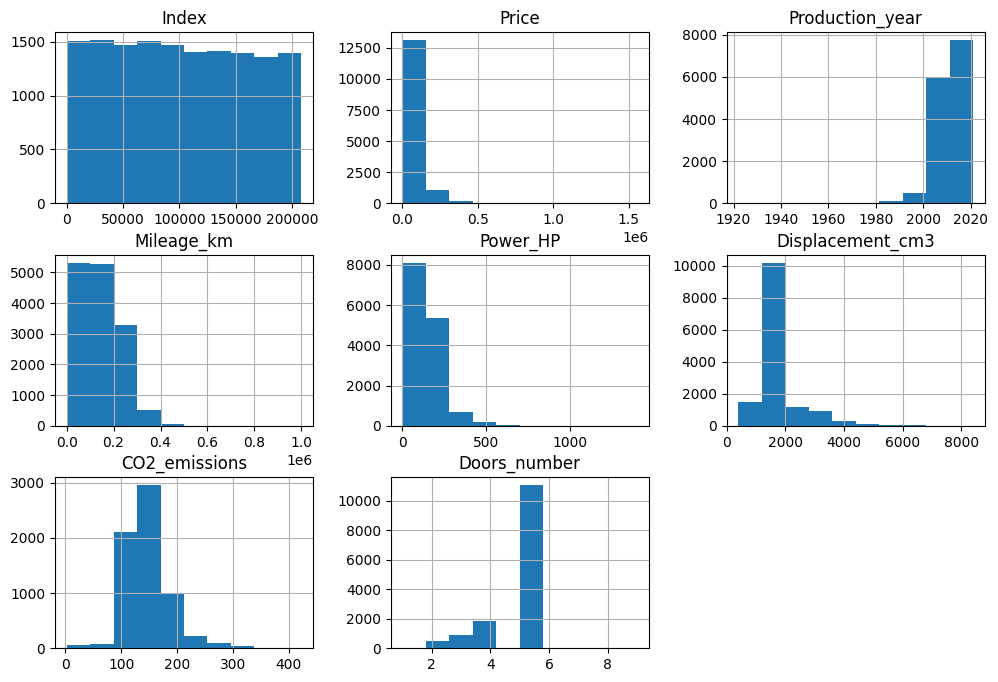

In [4]:
cars.hist(figsize=(12, 8))

In [ ]:
from sklearn.model_selection import train_test_split

train_set_df, test_set_df = train_test_split(cars, test_size=0.15 , random_state=0)
labels = train_set_df['Price']
test_labels = test_set_df['Price']

#train_set = train_set.drop(columns=['Price'])
#test_set = test_set.drop(columns=['Price'])

### Data analysis

In [124]:
tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency', 
                       'Doors_number' ]].copy()
for i, row in tmp_df.iterrows():
    if row['Currency'] == 'EUR':
        tmp_df.at[i, 'Price'] = row['Price'] * 4.26
tmp_df = tmp_df.drop(columns='Currency')
tmp_df['Condition'] = tmp_df['Condition'].map({'Used': 0, 'New': 1})
corr_mtx = tmp_df.corr()
corr_mtx['Price'].sort_values(ascending=False)

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\2528719430.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8051.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  tmp_df.at[i, 'Price'] = row['Price'] * 4.26


Price              1.000000
Power_HP           0.628924
Condition          0.444234
Production_year    0.410088
CO2_emissions      0.188188
Doors_number      -0.042903
Mileage_km        -0.505205
Name: Price, dtype: float64

In [7]:
dummies = pd.get_dummies(train_set_df['Vehicle_brand'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
corrs.sort_values(ascending=False).head(10)

Porsche          0.187021
Ferrari          0.157980
McLaren          0.153468
Bentley          0.139778
Lamborghini      0.133244
BMW              0.133079
Mercedes-Benz    0.125778
Land Rover       0.118499
Rolls-Royce      0.114679
Audi             0.075250
dtype: float64

In [126]:
# print(train_set['Type'].unique())
# print(train_set['Transmission'].unique())

dummies = pd.get_dummies(train_set_df['Type'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False), '\n')

dummies = pd.get_dummies(train_set_df['Transmission'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False), '\n')

dummies = pd.get_dummies(train_set_df['Drive'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False), '\n')

dummies = pd.get_dummies(train_set_df['Fuel_type'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False))

SUV              0.288929
coupe            0.131827
sedan            0.063268
convertible      0.047107
small_cars      -0.077725
minivan         -0.087670
station_wagon   -0.088786
compact         -0.116980
city_cars       -0.156929
dtype: float64 

Automatic    0.472969
Manual      -0.471245
dtype: float64 

4x4 (permanent)                 0.328217
4x4 (attached automatically)    0.242843
4x4 (attached manually)         0.054430
Rear wheels                     0.026218
Front wheels                   -0.313042
dtype: float64 

Hybrid            0.137053
Electric          0.132054
Gasoline          0.020124
Gasoline + CNG   -0.008438
Diesel           -0.052474
Gasoline + LPG   -0.092909
dtype: float64


##### Kategorie Korelacja testy

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#sns.set(style="whitegrid")

In [131]:
def correlation_ratio(categories, measurements):
    categories = np.asarray(categories)
    measurements = np.asarray(measurements, dtype=float)
    # drop NaNs pairwise
    mask = ~pd.isna(categories) & ~pd.isna(measurements)
    if mask.sum() == 0:
        return np.nan
    categories = categories[mask]
    measurements = measurements[mask]
    cat_codes, uniques = pd.factorize(categories)
    grand_mean = measurements.mean()
    ss_between = 0.0
    ss_total = ((measurements - grand_mean) ** 2).sum()
    for cat in np.unique(cat_codes):
        vals = measurements[cat_codes == cat]
        n_i = vals.size
        mean_i = vals.mean()
        ss_between += n_i * (mean_i - grand_mean) ** 2
    if ss_total == 0:
        return 0.0
    eta = np.sqrt(ss_between / ss_total)
    return float(eta)

In [132]:
features = ['Type', 'Transmission', 'Drive', 'Fuel_type']
results = []
df = train_set_df.copy()

for f in features:
    mask = df[f].notna() & df['Price'].notna()
    eta = correlation_ratio(df.loc[mask, f], df.loc[mask, 'Price'])
    # przygotuj grupy do ANOVA (potrzebne co najmniej 2 grupy z >1 próbką)
    groups = [g['Price'].values for _, g in df.loc[mask].groupby(f) if len(g) >= 2]
    if len(groups) >= 2:
        fstat, pval = stats.f_oneway(*groups)
    else:
        fstat, pval = np.nan, np.nan
    results.append((f, eta, fstat, pval))

res_df = pd.DataFrame(results, columns=['feature','eta','F_stat','pval']).set_index('feature')
res_df['neglog10_p'] = -np.log10(res_df['pval'].replace(0, 1e-300))  # zapobiega -inf
res_df

,eta,F_stat,pval,neglog10_p
feature,,,,
Type,0.375764,251.882193,0.000000e+00,300.000000
Transmission,0.472962,3526.680333,0.000000e+00,300.000000
Drive,0.454467,735.551464,0.000000e+00,300.000000
Fuel_type,0.213532,117.133045,2.075423e-121,120.682893


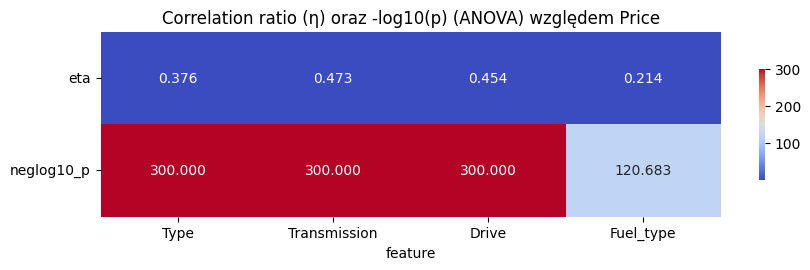

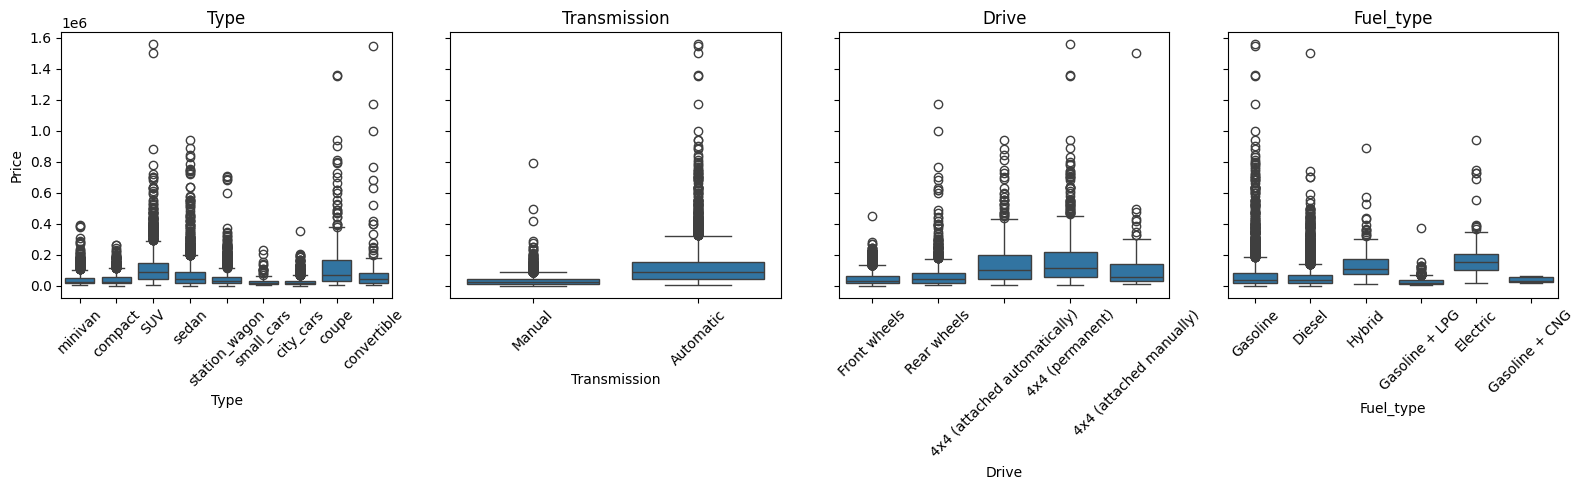

In [133]:
heat = res_df[['eta','neglog10_p']].T
plt.figure(figsize=(10, 2.4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap='coolwarm', cbar_kws={'shrink':0.6})
plt.yticks(rotation=0)
plt.title("Correlation ratio (η) oraz -log10(p) (ANOVA) względem Price")
plt.show()

# 5) boxploty (wizualna ocena rozkładu Price po kategoriach)
fig, axes = plt.subplots(1, len(features), figsize=(4*len(features), 5), sharey=True)
for ax, f in zip(axes, features):
    sns.boxplot(x=f, y='Price', data=df, ax=ax)
    ax.set_title(f)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

##### ----------------------------------

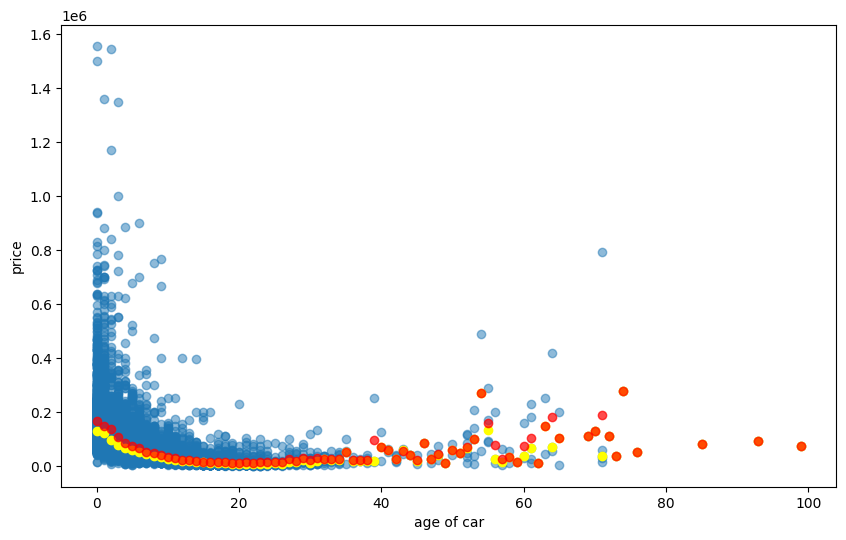

In [9]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
avg_prices = tmp_df.groupby('Years')['Price'].mean()
median_prices = tmp_df.groupby('Years')['Price'].median()
axis.scatter(tmp_df['Years'], tmp_df['Price'], alpha=0.5)
axis.scatter(median_prices.index, median_prices, c='yellow', alpha=1)
axis.scatter(avg_prices.index, avg_prices, c='red', alpha=0.7)
tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='age of car')
axis.set_ylabel(ylabel='price')
plt.show()

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\2821282248.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\2821282248.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


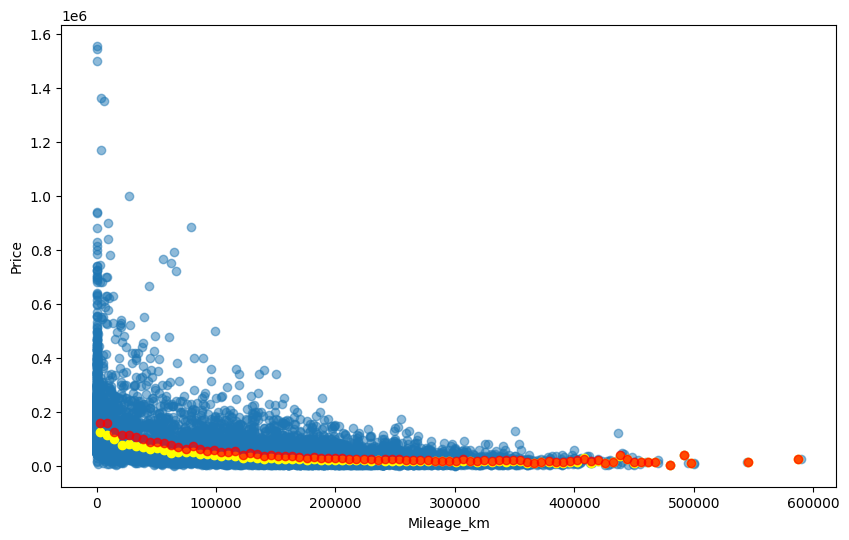

In [10]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=100)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()
# print(avg_prices)
# print(median_prices)
axis.scatter(tmp_df['Mileage_km'], tmp_df['Price'], alpha=0.5)
axis.scatter(indexes, median_prices['Price'], c='yellow', alpha=1)
axis.scatter(indexes, avg_prices['Price'], c='red', alpha=0.7)
# tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Price')
plt.show()

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\3465555353.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\3465555353.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


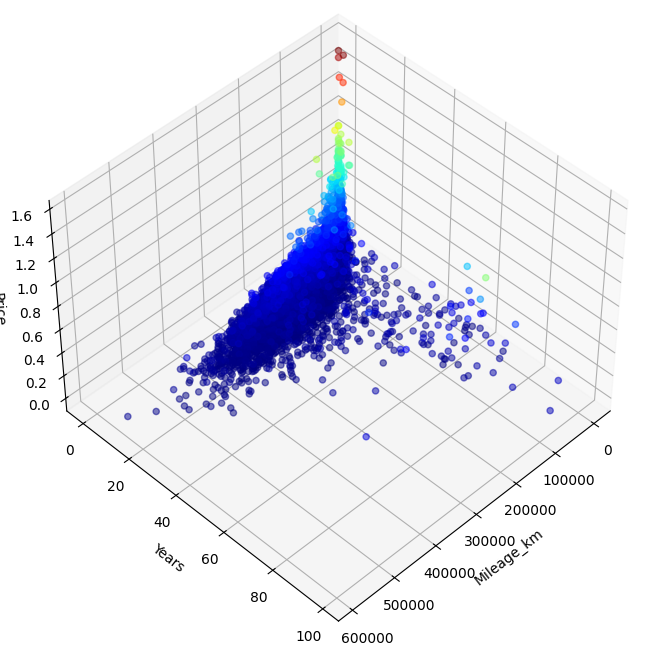

In [11]:
fig = plt.figure(figsize=(12, 8))
axis = plt.axes(projection='3d')

tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()

axis.scatter(tmp_df['Mileage_km'], tmp_df['Years'], tmp_df['Price'], alpha=0.5,
             c=tmp_df['Price'], cmap='jet') #viridis, jet
axis.view_init(azim=45, elev=45)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Years')
axis.set_zlabel(zlabel='Price')

plt.show()

### Pipeline

In [5]:
def currency_conversion(row, rules: dict):
    if row['Currency'] in rules:
        row['Price'] = row['Price'] * rules[row['Currency']]
    return row

from sklearn.base import BaseEstimator, TransformerMixin

class ExclusiveCars(BaseEstimator, TransformerMixin):
    def __init__(self, brand_col, ex_cars):
        self.brand_col = brand_col
        self.ex_cars = ex_cars
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X).copy()
        X[:, self.brand_col] = np.isin(X[:, self.brand_col], list(self.ex_cars)).astype(int)
        return X



In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

num_attributes = ['Years', 'Mileage_km', 'Power_HP', 'CO2_emissions', 'Vehicle_brand']
cat_attributes = ['Condition', 'Transmission', 'Type', 'Drive', 'Fuel_type']

"""
Used     Automatic     SUV               4x4 (permanent)                    Hybrid
New      Manual        coupe             4x4 (attached automatically)       Electric
                       sedan             4x4 (attached manually)            Gasoline
                       convertible       Rear wheels                        Gasoline + CNG 
                       small_cars        Front wheels                       Diesel 
                       minivan                                              Gasoline + LPG
                       station_wagon
                       compact      
                       city_cars    
"""
ex_cars = [
    "Porsche",
    "Ferrari",
    "McLaren",
    "Bentley",
    "Lamborghini",
    "BMW",
    "Mercedes-Benz",
    "Land Rover",
    "Rolls-Royce"
]

#Axis 0 will act on all the ROWS in each COLUMN
#Axis 1 will act on all the COLUMNS in each ROW
train_set_df.apply(lambda row: currency_conversion(row, {'EUR': 4.26}), axis=1)
train_set_df['Years'] = 2022 - train_set_df['Production_year']

######################TEST SETS###########################
test_set_df.apply(lambda row: currency_conversion(row, {'EUR': 4.26}), axis=1)
test_set_df['Years'] = 2022 - test_set_df['Production_year']


num_pipeline = Pipeline([
    ('exclusive-cars', ExclusiveCars(num_attributes.index('Vehicle_brand'), ex_cars)),
    ('imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one-hot-encoder', OneHotEncoder()),
])

final_pipeline = ColumnTransformer(transformers= [
    ('nums', num_pipeline, num_attributes),
    ('cats', cat_pipeline, cat_attributes),
],
remainder='drop',
n_jobs=-1,
)

train_set = final_pipeline.fit_transform(train_set_df)
test_set = final_pipeline.fit_transform(test_set_df)

In [138]:
train_set[0]

array([1.10e+01, 1.56e+05, 1.16e+02, 1.40e+02, 0.00e+00, 0.00e+00,
       1.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00])

### test outlinerów

Rozmiar oryginału: 12265 rozmiar po oczyszczeniu: 12019


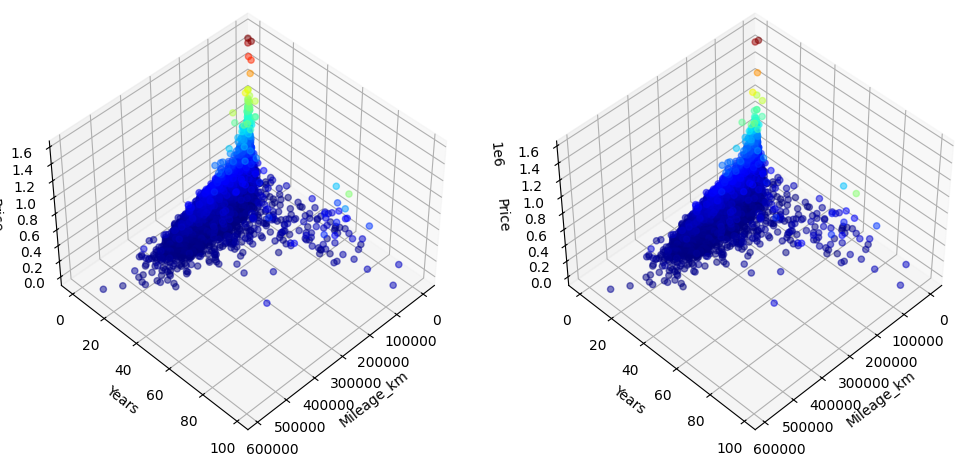

In [15]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.02,
    random_state=42
)

iso.fit(train_set)
is_outliner = iso.predict(train_set)


#-----------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 8),
    subplot_kw={'projection': '3d'}
)

ax1, ax2 = axes

tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']

tmp_df['is_outlier'] = is_outliner == -1
tmp_df_clean = tmp_df[~tmp_df['is_outlier']].drop(columns='is_outlier').reset_index(drop=True)
print("Rozmiar oryginału:", len(tmp_df), "rozmiar po oczyszczeniu:", len(tmp_df_clean))

lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2
tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
ax1.scatter(tmp_df['Mileage_km'], tmp_df['Years'], tmp_df['Price'], alpha=0.5,
             c=tmp_df['Price'], cmap='jet') #viridis, jet
ax1.view_init(azim=45, elev=45)
ax1.set_xlabel(xlabel='Mileage_km')
ax1.set_ylabel(ylabel='Years')
ax1.set_zlabel(zlabel='Price')

#----------------------------

lin = np.linspace(start=0, stop=tmp_df_clean['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2
tmp_df_clean['mileage_group'] = pd.cut(tmp_df_clean['Mileage_km'], bins=lin)
ax2.scatter(tmp_df_clean['Mileage_km'], tmp_df_clean['Years'], tmp_df_clean['Price'], alpha=0.5,
             c=tmp_df_clean['Price'], cmap='jet') #viridis, jet
ax2.view_init(azim=45, elev=45)
ax2.set_xlabel(xlabel='Mileage_km')
ax2.set_ylabel(ylabel='Years')
ax2.set_zlabel(zlabel='Price')
plt.show()

In [16]:
train_set_clean = train_set[is_outliner == 1]
labels_clean = labels[is_outliner == 1]
print(len(train_set_clean))
print(len(labels_clean))

12019
12019


In [148]:
train_set[0]

array([ 0.1173435 ,  0.20204772, -0.45585357, -0.10160113,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ])

### Models

In [8]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error as rmse
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import optuna

from joblib import dump, load
from datetime import datetime

def final_rmse_score(model, test_set, test_labels):
    final_mse = mean_squared_error(test_labels, model.predict(test_set))
    return np.sqrt(final_mse)

def final_evaluation(model, test_set, test_labels):
    #model.fit(test_set, test_labels)

    #predictions = model.predict(test_set)
    #errors = abs(predictions - test_labels)
    #mape = 100 * np.mean(errors / test_labels)
    #accuracy = 100 - mape
    
    print('Model Performance')
    #print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(1-mape(test_labels, model.predict(test_set))))
    print('final_rmse: ', final_rmse_score(model,test_labels))

def display_scores(scores):
    print('Model Performance')
    print('scores: ', scores)
    print('mean: ', scores.mean())
    print('standard deviation: ', scores.std())

# def fit_and_get_scores(model, train_set, labels):
#     scores = cross_val_score(model, train_set, labels,
#                              scoring='neg_mean_squared_error', cv=10)
#     scores = np.sqrt(-scores)
#     display_scores(scores)
    


e:\Python projects\komis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### RandomForest

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor

##### Base model

In [12]:
rtr_reg = RandomForestRegressor()
rtr_reg.fit(train_set, labels)

fname = f"MLmodels\\base_rtr_morecats{datetime.now().strftime('%Y%m%d_%H%M%S')}.joblib"
dump(rtr_reg, fname, compress=3)

['MLmodels\\base_rtr_morecats20260303_135810.joblib']

In [13]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(rtr_reg, train_set, labels, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_scores = -res["test_mape"]
rmse_scores = -res["test_rmse"]

In [14]:
display_scores(mape_scores)
print(1 - mape_scores.mean())
display_scores(rmse_scores)

Model Performance
scores:  [0.23818354 0.28263567 0.2585212  0.25713888 0.26425495 0.28345961
 0.26714463 0.30118468 0.2629938  0.26737566]
mean:  0.26828926304113776
standard deviation:  0.016403141910209845
0.7317107369588622
Model Performance
scores:  [31969.43113166 45113.18556478 28456.84323587 33589.00419355
 29166.4705129  38082.22931517 36042.98693075 27471.05754432
 25404.27873895 33006.11376391]
mean:  32830.16009318564
standard deviation:  5536.5971158838665


In [119]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, int(len(X_train)/80)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(1-mape(y_train[:m], y_train_predict))
        val_errors.append(1-mape(y_val, y_val_predict))

    plt.plot(train_errors, "r-+", linewidth=2, label="train")
    plt.plot(val_errors, "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("MAPE", fontsize=14)

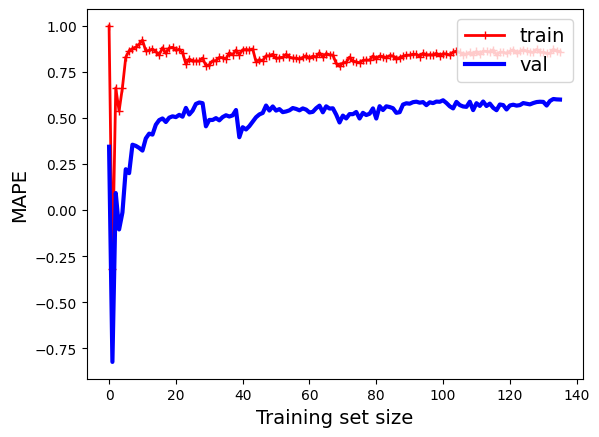

In [173]:
plot_learning_curves(rtr_reg, train_set, labels)

##### Cleaner data

In [17]:
crtr_reg = RandomForestRegressor()
crtr_reg.fit(train_set_clean, labels_clean)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(crtr_reg, train_set_clean, labels_clean, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_scores_clean = -res["test_mape"]
rmse_scores_clean = -res["test_rmse"]

In [18]:
display_scores(mape_scores_clean)
print(1 - mape_scores_clean.mean())
display_scores(rmse_scores_clean)

Model Performance
scores:  [0.23502502 0.26956739 0.26170404 0.24900252 0.26572176 0.28000536
 0.268326   0.30109259 0.26823603 0.27263327]
mean:  0.26713139852391227
standard deviation:  0.016579722680780347
0.7328686014760877
Model Performance
scores:  [35338.95298138 41350.17965019 25207.40619584 29151.57863779
 24454.0394144  27679.17039078 29367.56823194 26339.40833921
 24534.82840181 35180.33182612]
mean:  29860.34640694528
standard deviation:  5361.646281830076


Conclusion: not a big difference

##### Feature importances

In [19]:
feature_importances = rtr_reg.feature_importances_
nums = final_pipeline.named_transformers_["nums"]
cats = final_pipeline.named_transformers_["cats"]
num_features = num_attributes
ohe = cats.named_steps["one-hot-encoder"]
cat_features = ohe.get_feature_names_out(cat_attributes).tolist()
feature_names = num_features + cat_features
sorted(zip(feature_importances, feature_names), reverse=True)

[(np.float64(0.4730871778572439), 'Power_HP'),
 (np.float64(0.3161556254259642), 'Years'),
 (np.float64(0.10537164169159242), 'Mileage_km'),
 (np.float64(0.016568669913162252), 'CO2_emissions'),
 (np.float64(0.013504493951753325), 'Vehicle_brand'),
 (np.float64(0.012282111473836404), 'Fuel_type_Diesel'),
 (np.float64(0.009750149475961041), 'Drive_Front wheels'),
 (np.float64(0.007485200982020713), 'Type_convertible'),
 (np.float64(0.005433092651755641), 'Fuel_type_Gasoline'),
 (np.float64(0.004648852025012822), 'Type_SUV'),
 (np.float64(0.004002132446677214), 'Drive_4x4 (attached manually)'),
 (np.float64(0.0035812006242751694), 'Drive_4x4 (permanent)'),
 (np.float64(0.00338495882735134), 'Type_coupe'),
 (np.float64(0.0033436878433989238), 'Type_sedan'),
 (np.float64(0.0026748557719511908), 'Condition_Used'),
 (np.float64(0.002565325605204519), 'Condition_New'),
 (np.float64(0.002543235295804659), 'Transmission_Automatic'),
 (np.float64(0.002526432332707117), 'Transmission_Manual'),
 (

##### Hyperparameters

In [24]:
def find_good_forestreg():
    params = {'bootstrap': [True, False],
            'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
            'max_features': [2, 3, 4, 5, 6, None],
            'min_samples_leaf': [1, 2, 4],
            'min_samples_split': [2, 5, 10],
            'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}
    forest_reg = RandomForestRegressor()

    random_search = RandomizedSearchCV(estimator=forest_reg, param_distributions=params,
                                    n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=3)

    random_search.fit(train_set, labels)
    print(random_search.best_params_)
    print(random_search.best_estimator_)
    #evaluate(random_search.best_estimator_, test_set, test_labels)

def find_better_forestreg():
    params = {
        'bootstrap': [True],
        'max_depth': [10], #'max_depth': [7, 10, 13],
        'max_features': [10], #'max_features': [10, 15, None],
        'min_samples_leaf': [1, 2],
        'min_samples_split': [4, 5, 6],
        'n_estimators': [1300, 1400, 1500]
        }
    forest_reg = RandomForestRegressor()

    grid_search = GridSearchCV(estimator=forest_reg, param_grid=params,
                                  cv=3, n_jobs=-1, verbose=3)
    grid_search.fit(train_set, labels)
    print(grid_search.best_params_)
    print(grid_search.best_estimator_)
    #evaluate(grid_search.best_estimator_, test_set, test_labels)

In [20]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 1300, 1600)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 5, 10, 15, None])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42,
        n_jobs=-1
    )

    # score = cross_val_score(model, train_set, labels, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    # rmse_score = float(np.mean(np.sqrt(-score)))
    #cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    preds = cross_val_predict(model, train_set, labels, cv=5, n_jobs=-1)
    rmse_score = rmse(labels, preds)
    mape_score = mape(labels, preds)
    trial.set_user_attr("rmse", float(rmse_score))
    trial.set_user_attr("mape", float(1 - mape_score))
    #return float(rmse_score)
    return float(1 - mape_score)

In [21]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2026-03-03 14:01:38,125] A new study created in memory with name: no-name-abc545bc-88df-4280-84dc-5c9f44580ef5
[I 2026-03-03 14:02:01,554] Trial 0 finished with value: 0.7260392719725428 and parameters: {'n_estimators': 1412, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 10, 'bootstrap': False}. Best is trial 0 with value: 0.7260392719725428.
[I 2026-03-03 14:02:21,211] Trial 1 finished with value: 0.6511120979740674 and parameters: {'n_estimators': 1550, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 15, 'bootstrap': False}. Best is trial 0 with value: 0.7260392719725428.
[I 2026-03-03 14:03:01,148] Trial 2 finished with value: 0.7332968347036211 and parameters: {'n_estimators': 1437, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.7332968347036211.
[I 2026-03-03 14:03:12,689] Trial 3 finished with value: 0.53393048117931 and para

In [22]:
best_params = study.best_params
print(f"Best Hyperparameters: {best_params}")
best_score = study.best_value
print(f"Best Accuracy: {best_score:.3f}")

Best Hyperparameters: {'n_estimators': 1437, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}
Best Accuracy: 0.733


In [24]:
#best_params = {'bootstrap': True, 'max_depth': 10, 'max_features': 10, 'n_estimators': 1500, 'min_samples_leaf': 1, 'min_samples_split': 4}
best_params = {'n_estimators': 1543, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 10, 'bootstrap': True}

forest_reg = RandomForestRegressor(**best_params)
forest_reg.fit(train_set_clean, labels_clean)

fname = f"MLmodels\\hyper_rtr_morecats{datetime.now().strftime('%Y%m%d_%H%M%S')}.joblib"
dump(rtr_reg, fname, compress=3)

['MLmodels\\hyper_rtr_morecats20260303_140825.joblib']

In [25]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(forest_reg, train_set_clean, labels_clean, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_scores_hyper = -res["test_mape"]
rmse_scores_hyper = -res["test_rmse"]

In [184]:
display_scores(mape_scores_hyper)
print(1 - mape_scores_hyper.mean())
display_scores(rmse_scores_hyper)

Model Performance
scores:  [0.24374511 0.27794464 0.27008774 0.2625019  0.26609014 0.29807849
 0.26385185 0.28561262 0.26767241 0.26369338]
mean:  0.26992782974093305
standard deviation:  0.01392496715228985
0.7300721702590669
Model Performance
scores:  [31100.77025331 37018.96551729 27790.27170211 24006.73665387
 22866.46723302 26028.37762674 27745.12712318 22690.48108736
 23360.00726479 27349.62268068]
mean:  26995.68271423493
standard deviation:  4210.808106897934


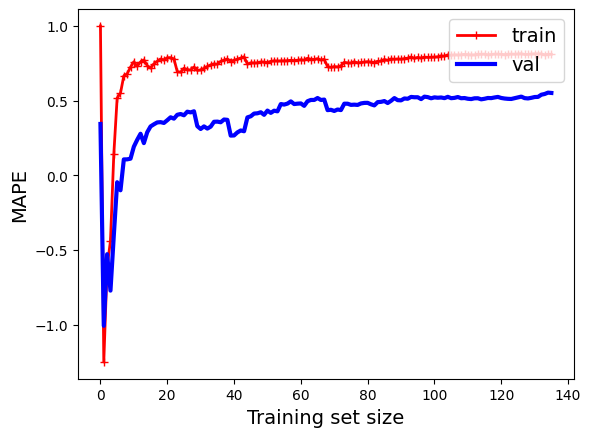

In [185]:
plot_learning_curves(forest_reg, train_set, labels)

In [26]:
#best_params = {'n_estimators': 1400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
#best_params = {'bootstrap': True, 'max_depth': 10, 'max_features': 10, 'n_estimators': 1500, 'min_samples_leaf': 1, 'min_samples_split': 4}
best_params = {'n_estimators': 1543, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 10, 'bootstrap': True}

base = RandomForestRegressor(**best_params)
model = TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1)
model.fit(train_set, labels)

fname = f"MLmodels\\hypertargreg_rtr_morecats{datetime.now().strftime('%Y%m%d_%H%M%S')}.joblib"
dump(model, fname, compress=3)

['MLmodels\\hypertargreg_rtr_morecats20260303_141113.joblib']

In [27]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(model, train_set_clean, labels_clean, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_scores_hyper = -res["test_mape"]
rmse_scores_hyper = -res["test_rmse"]

In [28]:
display_scores(mape_scores_hyper)
print(1 - mape_scores_hyper.mean())
display_scores(rmse_scores_hyper)

Model Performance
scores:  [0.21043711 0.22852271 0.24469028 0.22693891 0.24623483 0.25425191
 0.23152717 0.25000914 0.2412348  0.23715688]
mean:  0.23710037310263393
standard deviation:  0.012400705821996648
0.762899626897366
Model Performance
scores:  [39292.099577   45039.97349083 26901.18385583 42132.53567324
 22994.24987783 28771.20054791 34130.23330688 21871.05639439
 21983.43583476 29768.74218741]
mean:  31288.47107460713
standard deviation:  8067.16331049586


### LGBMRegressor

In [133]:
from lightgbm import LGBMRegressor

def find_good_lgbmreg():
    params = {
        'n_estimators': [300, 500, 800, 1200, 2000],
        'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
        'num_leaves': [15, 31, 63, 127],
        'max_depth': [-1, 5, 7, 9, 12],
        'min_child_samples': [10, 20, 30, 50, 100],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
        'reg_lambda': [0.0, 0.1, 0.5, 1.0]
    }

    lgbmreg = LGBMRegressor(objective='regression')

    lgbmreg_random_search = RandomizedSearchCV(estimator=lgbmreg, param_distributions=params,
                                    n_iter=15, cv=5, random_state=42, n_jobs=-1, verbose=3)

    lgbmreg_random_search.fit(train_set, labels)
    print(lgbmreg_random_search.best_params_)
    print(lgbmreg_random_search.best_estimator_)
    #final_evaluation(lgbmreg_random_search.best_estimator_, test_set, test_labels)

find_good_lgbmreg()

Fitting 5 folds for each of 15 candidates, totalling 75 fits


KeyboardInterrupt: 

In [33]:
best_params = {'subsample': 0.6, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 1200, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

lgbmreg = LGBMRegressor(**best_params)
lgbmreg.fit(train_set, labels)

fname = f"MLmodels\\lgbmreg{datetime.now().strftime('%Y%m%d_%H%M%S')}.joblib"
dump(model, fname, compress=3)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 12265, number of used features: 28
[LightGBM] [Info] Start training from score 64301.336078
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

['MLmodels\\lgbmreg20260303_143452.joblib']

In [34]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(model, train_set_clean, labels_clean, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_scores_hyper = -res["test_mape"]
rmse_scores_hyper = -res["test_rmse"]

In [35]:
display_scores(mape_scores_hyper)
print(1 - mape_scores_hyper.mean())
display_scores(rmse_scores_hyper)

Model Performance
scores:  [0.2104894  0.22902312 0.24461781 0.22669605 0.24584733 0.25435161
 0.2313498  0.24974769 0.24081739 0.23747958]
mean:  0.23704197741386687
standard deviation:  0.012325630581914934
0.7629580225861331
Model Performance
scores:  [39418.74540043 45417.90329232 26810.51617581 42383.55614694
 22922.75260292 28807.87246509 34203.75190675 21926.18695576
 21945.55818381 29864.43778831]
mean:  31370.12809181364
standard deviation:  8188.017238062042


### HistGradientBoostingRegressor

In [37]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbreg_params = {
    "max_iter": [100, 200, 500, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_leaf_nodes": [31, 63, 127, None],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0],
    "max_bins": [16, 32, 64, 128, 255],
    "categorical_features": [None],
}

hgbreg = HistGradientBoostingRegressor()

hgbreg_random_search = RandomizedSearchCV(estimator=hgbreg, param_distributions=hgbreg_params,
                                   n_iter=15, cv=5, random_state=42, n_jobs=-1, verbose=3)

hgbreg_random_search.fit(train_set, labels)
print(hgbreg_random_search.best_params_)
print(hgbreg_random_search.best_estimator_)
#final_evaluation(hgbreg_random_search.best_estimator_, test_set, test_labels)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
{'min_samples_leaf': 50, 'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 5, 'max_bins': 255, 'learning_rate': 0.01, 'l2_regularization': 0.1, 'categorical_features': None}
HistGradientBoostingRegressor(categorical_features=None, l2_regularization=0.1,
                              learning_rate=0.01, max_depth=5, max_iter=1000,
                              max_leaf_nodes=127, min_samples_leaf=50)


In [ ]:
final_evaluation(hgbreg_random_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.65%.
final_rmse:  30663.968449787688


### SVM

In [191]:
from sklearn.svm import SVR

def find_good_svm():
    params = {
        'C': [10, 100, 1000, 2000, 2500, 3000, 3500, 4000],
        'epsilon': [0.5, 0.7, 1.0, 1.5, 2, 2.5, 3, 3.5],
        'gamma': ['scale', 'auto', 0.005, 0.01, 0.05, 0.1, 0.2, 0.5],
        'kernel': ['rbf']
    }
    svm = SVR()

    svm_random_search = RandomizedSearchCV(estimator=svm, param_distributions=params,
                                    n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=3)

    svm_random_search.fit(train_set, labels)
    print(svm_random_search.best_params_)
    print(svm_random_search.best_estimator_)
    evaluate(svm_random_search.best_estimator_, test_set, test_labels)

find_good_svm()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 3, 'C': 4000}
SVR(C=4000, epsilon=3, gamma='auto')


In [259]:
best_params = {'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 3, 'C': 4000}

svmreg = SVR(**best_params)
svmreg.fit(train_set_clean, labels_clean)
print()

In [260]:
evaluate(svmreg, test_set, test_labels)

Model Performance
Accuracy = 0.73%.
final_rmse:  56605.14005747156


In [194]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

params = {
    'C': [4000, 4500, 5000],
    'epsilon': [3, 3.5, 4, 4.5],
    'gamma': ['auto'],
    'kernel': ['rbf']
}
svm = SVR()

grid_search = GridSearchCV(estimator=svm, param_grid=params,
                            cv=3, n_jobs=-1, verbose=3,
                            return_train_score=True)

grid_search.fit(train_set, labels)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'C': 5000, 'epsilon': 3, 'gamma': 'auto', 'kernel': 'rbf'}
SVR(C=5000, epsilon=3, gamma='auto')


In [195]:
evaluate(grid_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.69%.
final_rmse:  56871.59195511421


### Final model

In [151]:
from sklearn.base import BaseEstimator, TransformerMixin

class ExclusiveCars(BaseEstimator, TransformerMixin):
    def __init__(self, brand_col, ex_cars):
        self.brand_col = brand_col
        self.ex_cars = ex_cars
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = np.asarray(X).copy()
        X_copy[:, self.brand_col] = np.isin(X[:, self.brand_col], list(self.ex_cars)).astype(int)
        return X_copy

class CurrencyConverter(BaseEstimator, TransformerMixin):
    def __init__(self, rules: dict = None):
        self.rules = rules
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        if 'Price' not in X_copy.columns or 'Currency' not in X_copy.columns:
            return X_copy
    
        X_copy['Price'] = X_copy['Price'].astype(float)
        rates = X_copy['Currency'].map(self.rules)
        mask = rates.notna()
        X_copy.loc[mask, 'Price'] = X_copy.loc[mask, 'Price'] * rates[mask].astype(float)
        
        return X_copy

class YearsExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, current_year: int = 2022, target_col: str = 'Production_year', out_col: str = 'Years'):
        self.current_year = current_year
        self.target_col = target_col
        self.out_col = out_col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        if self.target_col not in X_copy.columns:
            return X_copy
            
        prod = pd.to_numeric(X_copy[self.target_col], errors='coerce')
        X_copy[self.out_col] = (self.current_year - prod).astype(float)
        
        return X_copy

##### Random forest and LGMB pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

import sklearn
sklearn.set_config(transform_output="default")

num_attributes = ['Years', 'Mileage_km', 'Power_HP', 'CO2_emissions', 'Vehicle_brand']
cat_attributes = ['Condition', 'Transmission', 'Type', 'Drive', 'Fuel_type']

ex_cars = [
    "Porsche",
    "Ferrari",
    "McLaren",
    "Bentley",
    "Lamborghini",
    "BMW",
    "Mercedes-Benz",
    "Land Rover",
    "Rolls-Royce"
]

rules = {'EUR': 4.26}

num_pipeline = Pipeline([
    ('exclusive-cars', ExclusiveCars(num_attributes.index('Vehicle_brand'), ex_cars)),
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one-hot-encoder', OneHotEncoder()),
])

coltrans = ColumnTransformer(transformers=[
    ('nums', num_pipeline, num_attributes),
    ('cats', cat_pipeline, cat_attributes),
], 
remainder='drop',
n_jobs=1)

preproc_pipeline = Pipeline([
    ('currency', CurrencyConverter(rules)),
    ('years', YearsExtractor(current_year=2022)),
    ('coltrans', coltrans),
], verbose=True)

In [115]:
best_params = {'n_estimators': 1543, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 10, 'bootstrap': True}
base = RandomForestRegressor(**best_params)
rf = TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1)

rf_pipeline = Pipeline([
    ('prep', preproc_pipeline),
    ('rf', rf)
])

In [150]:
rf_pipeline.fit(train_set_df, labels)
print(1 - mape(test_labels, rf_pipeline.predict(test_set_df)))

[Pipeline] .......... (step 1 of 3) Processing currency, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing years, total=   0.0s
[Pipeline] .......... (step 3 of 3) Processing coltrans, total=   2.1s
0.7758461317724512


In [152]:
best_params = {'subsample': 0.6, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 1200,
               'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
lgbmreg = LGBMRegressor(**best_params)

lgbm_preproc = sklearn.base.clone(preproc_pipeline)
lgbm_pipeline = Pipeline([
    ('prep', lgbm_preproc),
    ('lgbm', lgbmreg)
])

RuntimeError: Cannot clone object CurrencyConverter(rules={'EUR': 4.26}), as the constructor either does not set or modifies parameter rules

In [146]:
print(preproc_pipeline.fit_transform(train_set_df).shape)
#lgbm_pipeline.fit(train_set_df, labels)
#print(1 - mape(test_labels, rf_pipeline.predict(test_set_df)))

[Pipeline] .......... (step 1 of 3) Processing currency, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing years, total=   0.0s


InvalidIndexError: (slice(None, None, None), 4)

##### CatBoost pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_attributes = ['Years', 'Mileage_km', 'Power_HP', 'CO2_emissions']
cat_attributes = ['Condition', 'Transmission', 'Type', 'Vehicle_brand']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

final_pipeline = ColumnTransformer(transformers= [
    ('nums', num_pipeline, num_attributes),
    ('cats', cat_pipeline, cat_attributes),
],
remainder='drop',
n_jobs=-1,
)

catboost_train_set = final_pipeline.fit_transform(train_set_df)
catboost_test_set = final_pipeline.fit_transform(test_set_df)

print(catboost_train_set[0])

from catboost import CatBoostRegressor

model = CatBoostRegressor(cat_features=[4, 5, 6, 7])
model.fit(catboost_train_set, labels)
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape
final_mse = mean_squared_error(test_labels, model.predict(catboost_test_set))
print(np.sqrt(final_mse))
print('Accuracy = {:0.2f}%.'.format(1-mape(test_labels, model.predict(catboost_test_set))))

[11.0 156000.0 116.0 140.0 'Used' 'Manual' 'minivan' 'Nissan']
Learning rate set to 0.06084
0:	learn: 83439.8992421	total: 148ms	remaining: 2m 28s
1:	learn: 79879.2913011	total: 167ms	remaining: 1m 23s
2:	learn: 76681.0944005	total: 186ms	remaining: 1m 1s
3:	learn: 73740.9115334	total: 205ms	remaining: 51.1s
4:	learn: 70963.7430044	total: 226ms	remaining: 45s
5:	learn: 68416.5276015	total: 245ms	remaining: 40.7s
6:	learn: 66046.4223867	total: 264ms	remaining: 37.5s
7:	learn: 63716.6445385	total: 283ms	remaining: 35.1s
8:	learn: 61567.0349593	total: 302ms	remaining: 33.2s
9:	learn: 59534.7013522	total: 321ms	remaining: 31.8s
10:	learn: 57722.3995585	total: 340ms	remaining: 30.5s
11:	learn: 56119.4159888	total: 358ms	remaining: 29.5s
12:	learn: 54616.2853238	total: 378ms	remaining: 28.7s
13:	learn: 53103.3759072	total: 399ms	remaining: 28.1s
14:	learn: 51755.5348182	total: 421ms	remaining: 27.6s
15:	learn: 50577.1652822	total: 441ms	remaining: 27.1s
16:	learn: 49403.1378732	total: 462ms	